# 02 Repurchase Diagnosis

本 notebook 的重点不是先讨论“延迟是否导致复购”，而是先利用创建的用户粒度 RFM 表中的 `eligible_repurchase_90d` 与 `repurchase_within_90d` 建立可信的 `90d` 复购口径，来判断平台是否具备高频复购特征。

叙事顺序与仓库主线保持一致：先确认用户粒度与右删失防御，再给出低复购现实，最后把延迟均值差异当作补充性的风险信号，而不是直接归因。

## Section 0: Setup

In [1]:
# ======================================================
# Section 0 (Cell 1/1): Load Data & Setup
# ======================================================

import os
import sys
from pathlib import Path
from datetime import datetime, timezone, timedelta

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from sqlalchemy import create_engine
import yaml

try:
    from dotenv import load_dotenv
except Exception:  # pragma: no cover
    load_dotenv = None

# Timezone anchoring for reproducibility
TZ_UTC8 = timezone(timedelta(hours=8))
run_ts_utc8 = datetime.now(TZ_UTC8).strftime('%Y-%m-%d %H:%M:%S %z')
print(f'[UTC+8] Run timestamp: {run_ts_utc8}')

# Project root resolution (avoid hardcoding)
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

# Load config (config.yml / config.yaml)
config_candidates = [project_root / 'configs' / 'config.yaml', project_root / 'configs' / 'config.yml']
config_path = next((p for p in config_candidates if p.exists()), None)
if config_path is None:
    raise FileNotFoundError(f"No config file found. Searched: {[str(p) for p in config_candidates]}")
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Figures output
figures_dir = Path(config['paths']['figures_dir'])
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Figures will be saved to: {figures_dir}")

# Build engine (prefer DATABASE_URL, fallback to discrete vars)
database_url = os.getenv('DATABASE_URL')
if database_url:
    engine = create_engine(database_url)
else:
    USER = os.getenv('DB_USER')
    PASSWORD = os.getenv('DB_PASS')
    HOST = os.getenv('DB_HOST', 'localhost')
    PORT = os.getenv('DB_PORT', '5432')
    DB = os.getenv('DB_NAME')

    missing = [k for k, v in {'DB_USER': USER, 'DB_PASS': PASSWORD, 'DB_NAME': DB}.items() if not v]
    if missing:
        raise RuntimeError('Missing required env vars (or set DATABASE_URL): ' + ', '.join(missing))

    engine = create_engine(f'postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}')

df_rfm = pd.read_sql('SELECT * FROM analysis.analysis_user_rfm', engine)
assert len(df_rfm) > 0, 'Loaded analysis_user_rfm is empty'

# Basic check
df_rfm.shape, df_rfm.describe()

[UTC+8] Run timestamp: 2026-03-09 00:40:38 +0800
Figures will be saved to: outputs\figures


((93350, 20),
           frequency      monetary  avg_delay_days  severe_late_rate  \
 count  93350.000000  93350.000000    93350.000000      93350.000000   
 mean       1.033423    165.196388      -11.150558          0.053807   
 std        0.209106    226.322448       10.140914          0.224330   
 min        1.000000      0.000000     -146.016123          0.000000   
 25%        1.000000     63.050000      -16.227124          0.000000   
 50%        1.000000    107.780000      -11.745674          0.000000   
 75%        1.000000    182.547500       -6.392494          0.000000   
 max       15.000000  13664.080000      188.975081          1.000000   
 
        eligible_repurchase_90d  repurchase_within_90d  monetary_90d  \
 count             93350.000000           75385.000000  93350.000000   
 mean                  0.807552               0.012973    163.531332   
 std                   0.394225               0.113160    224.726393   
 min                   0.000000               0.

## Section 1: Low-Repurchase Reality (90d vs long)

90d窗口复购率(eligible only): 1.30%
Eligible users: 75385/93350
.png already saved: outputs\figures\fig_02_ltv90_vs_ltvlong.png


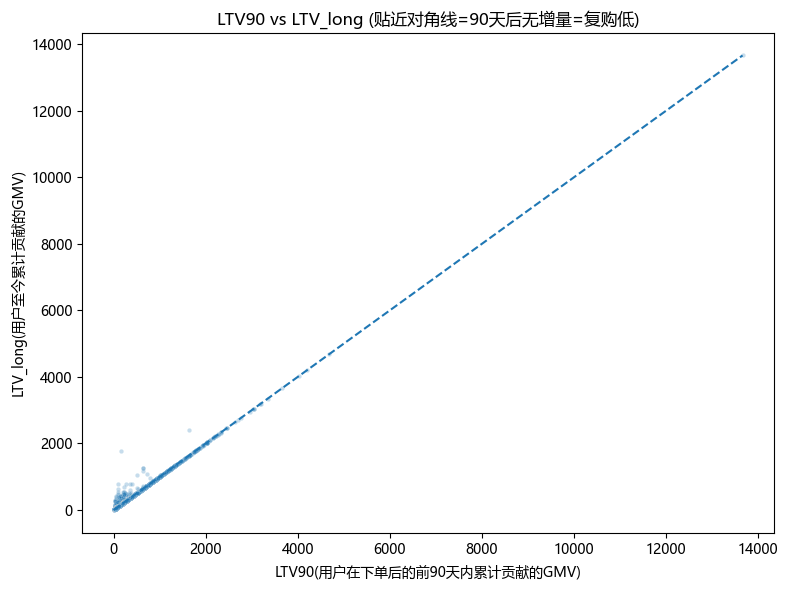

In [ ]:
# ======================================================
# Section 1 (Cell 1/1): Repurchase Rate & LTV
# ======================================================
# 逻辑: 通过用户在首单后续是否还有下单来计算复购率,为后续分析做数据准备

# --------------------------
# 1) Compute Repurchase Rate
# --------------------------
# Attention: 分析时间点定为数据集最大时间 + 1 天

# 90d 窗口复购(右删失防御): 仅在 eligible 用户上计算
# eligible 用户: 首单距离至今超过 90d 的用户 (避免把 "还没来得及复购的用户" 误判为 "不复购")
df_rfm_elig = df_rfm[df_rfm["eligible_repurchase_90d"] == 1].copy()
df_rfm_elig["is_repurchase_90d"] = df_rfm_elig["repurchase_within_90d"].astype("int8")

# 计算核心指标(复购率)
repurchase_rate = df_rfm_elig["is_repurchase_90d"].mean()
churn_rate = 1 - repurchase_rate

print(f"90d窗口复购率(eligible only): {repurchase_rate:.2%}")
print(f"Eligible users: {len(df_rfm_elig)}/{len(df_rfm)}")

# ----------------------------
# 2) LTV Data Show
# ----------------------------

# 避免中文无法正常显示
mpl.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]

col_90,col_long = "monetary_90d","monetary_long"
p0 = df_rfm[[col_90, col_long]].dropna()
p = p0.sample(min(20000, len(p0)), random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=p,x=col_90,y=col_long,s=10,alpha=0.25)

m = p[[col_90, col_long]].to_numpy().max()
plt.plot([0, m], [0, m], "--")  # y=x 参考线
plt.title("LTV90 vs LTV_long (贴近对角线=90天后无增量=复购低)")
plt.xlabel("LTV90(用户在下单后的前90天内累计贡献的GMV)")
plt.ylabel("LTV_long(用户至今累计贡献的GMV)")
plt.tight_layout()
fig = plt.gcf()

out = figures_dir / 'fig_02_ltv90_vs_ltvlong.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
print(f'.png already saved: {out}')
plt.show()


### Section 1 Summary

**Workflow**:
- 在 `analysis.analysis_user_rfm` 中，只对 `eligible_repurchase_90d=1` 的用户计算 `repurchase_within_90d`，先把 `90d` 复购分母固定住。
- 用 `monetary_90d` 与 `monetary_long` 的关系，补充观察价值是否明显延后释放。

**Core Figure**:
- Eligible 用户 `90d` 复购率仅 `1.30%`。
- `monetary_90d` 与 `monetary_long` 的均值接近（`163.53` vs `165.20`），说明大部分价值集中在首单后较短窗口内。
- `monetary_long` 分布长尾明显，少数高价值用户会显著抬高均值。

**Explanation**:
- 这个 notebook 回答 “复购是否稀少、价值是否后移” ，不直接证明哪种动作会提升复购。
- `LTV90` 与 `LTV_long` 的关系只提供支持性证据；更核心的结论仍是低复购现实，而不是高频复购逻辑。

**Insight**:
- 在 `1%` 量级的基线下，后续动作应优先回到首单质量、体验底线和入口筛选，而不是默认把增长故事建立在频繁复购上。
- 因此，后续更值得衔接的是钩子品类筛选和供给稳定性，而不是直接把这组结果包装成“复购运营空间很大”。

**Artifacts**:
- 已保存图表: `outputs/figures/fig_02_ltv90_vs_ltvlong.png`


## Section 2: Fulfillment Signal Check (T-test + state stratification)


 1. 整体T-Test检验
平均延迟天数 (流失组): -10.91 days
平均延迟天数 (复购组): -11.57 days
检验P值: 6.0158e-03 (显著)

 2. (MG)分层T-Test检验
平均延迟天数 (流失组): -12.22 days
平均延迟天数 (复购组): -13.04 days
检验P值: 1.8727e-01 (不显著)
.png already saved: outputs\figures\fig_02_top3_state_delay_by_repurchase.png


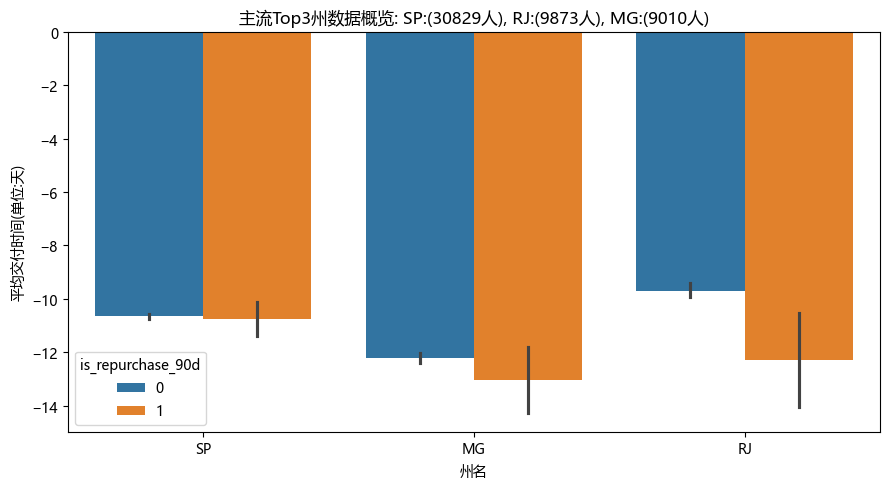

In [ ]:
# ======================================================
# Section 2 (Cell 1/1): Fulfillment Signal Check
# ======================================================

# ---------------------------
# 1) Overall T-Test (Basic)
# ---------------------------
# Logic: 把用户分成两组:复购组,流失组
group_repurchase = df_rfm_elig[df_rfm_elig["is_repurchase_90d"] == 1]["avg_delay_days"].dropna()
group_churned = df_rfm_elig[df_rfm_elig["is_repurchase_90d"] == 0]["avg_delay_days"].dropna()

# 做两独立样本均值差异检验
t_stat, p_val = stats.ttest_ind(group_churned, group_repurchase, equal_var=False)

print(f"\n 1. 整体T-Test检验")
print(f"平均延迟天数 (流失组): {group_churned.mean():.2f} days")
print(f"平均延迟天数 (复购组): {group_repurchase.mean():.2f} days")
print(f"检验P值: {p_val:.4e} ({'显著' if p_val < 0.05 else '不显著'})")


# -----------------------------
# 2) Hierarchical T-Test (Deep)
# -----------------------------
# 解决问题:整体均值差是否主要来自地区构成差异,而不是履约信号本身
# 逻辑:在同一个州内部进行T-Test(以"MP"为例子),查看延迟差异是否仍然稳定
#      如果州内差异仍存在,只能说明延迟信号值得继续做控制变量分析,不能直接当作归因结论
state = 'MP'
test_state = df_rfm_elig[df_rfm_elig["primary_state"] == state]

group_state_repurchase = test_state[test_state["is_repurchase_90d"] == 1]["avg_delay_days"].dropna()
group_state_churned  = test_state[test_state["is_repurchase_90d"] == 0]["avg_delay_days"].dropna()

t_stat, p_val = stats.ttest_ind(group_state_churned, group_state_repurchase, equal_var=False)

print(f"\n 2. ({state})分层T-Test检验")
print(f"平均延迟天数 (流失组): {group_state_churned.mean():.2f} days")
print(f"平均延迟天数 (复购组): {group_state_repurchase.mean():.2f} days")
print(f"检验P值: {p_val:.4e} ({'显著' if p_val < 0.05 else '不显著'})")


# --------------------------------
# 3) 所有主流州数据概况
# --------------------------------
# 逻辑:给出用户数最多的Top3州数据概览
# 按用户数计算得出Top3 primary_state
top3_counts = (
    df_rfm_elig["primary_state"]
    .dropna()
    .value_counts()
    .head(3)
)

# Top3
top3_states = top3_counts.index.to_list()
top3_user_counts = top3_counts.to_dict()

df_top3 = df_rfm_elig[df_rfm_elig["primary_state"].isin(top3_states)]
plt.figure(figsize=(9, 5))
sns.barplot(
    x='primary_state',
    y='avg_delay_days',
    hue='is_repurchase_90d',
    data=df_top3,
    # 95% CI
    errorbar=("ci",95)
)
plt.xlabel('州名')
plt.ylabel('平均交付时间(单位:天)')
plt.title('主流Top3州数据概览: ' + ', '.join([f"{s}:({top3_user_counts[s]}人)" for s in top3_states]))
plt.tight_layout()
fig = plt.gcf()
out = figures_dir / 'fig_02_top3_state_delay_by_repurchase.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
print(f'.png already saved: {out}')
plt.show()

### Section 2 Summary

**Workflow**:
- 用 Welch's T-test (`equal_var=False`) 比较 `avg_delay_days` 在复购组与未复购组之间的均值差异。
- 以 `primary_state='MG'` 做一个州内分层示例，再用 Top3 州图做分布 sanity check，判断整体均值差是否可能主要来自构成差异。

**Core Figures**:
- 整体样本里，未复购组 `-10.91` days，复购组 `-11.57` days，`p=6.0158e-03`。
- `MG` 州内，未复购组 `-12.22` days，复购组 `-13.04` days，`p=1.8727e-01`，稳定性明显变弱。
- 两组均值都为负，说明样本整体更接近‘准时/提前交付’，这里看到的是均值差异，不是履约断崖本身。
- 但在 `RJ` 州内，未复购组和复购组间的差异又非常显著

**Explanation**:
- 这一步只能算补充性的风险信号检查，不应被表述为“履约延迟已经被归因到复购下降”。
- 总体显著、个别分层显著、其余分层不显著，说明均值差很可能仍受州分布、品类结构和用户构成影响。
- 如果要看更稳定的履约风险，应回到 notebook 01 的 `Late_Small -> Late_Severe` 断崖，而不是把这里的均值差直接当成主结论。

**Insights**:
- 可以把 `avg_delay_days` 视作需要继续分层和控制变量的辅助信号，但不适合直接写成因果结论。
- 这个结果更适合支持“体验底线值得守住”，不适合单独支撑“延迟均值每改善一天就能显著拉动复购”。

**Artifacts**:
- 已保存图表: `outputs/figures/fig_02_top3_state_delay_by_repurchase.png`
